# 04 — Machine Learning Methods

**Project:** What Makes a Song Popular? A Data Analysis of Spotify Tracks

This notebook applies machine learning methods to the Spotify dataset. It follows the same logic as the example notebook, but adapted to this project.

Main goals:

1. **Classification:** Predict whether a song belongs to the high-popularity or low-popularity group.
2. **Regression:** Predict the numeric Spotify popularity score.
3. **Model evaluation:** Compare multiple models using accuracy, F1-score, RMSE, MAE, and R².
4. **Visualization:** Use confusion matrix, ROC curve, feature importance, actual-vs-predicted scatter plot, and residual histogram.

All plots are saved inside the `figures/` folder.


## 0. Imports and Helper Functions

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.inspection import permutation_importance

np.random.seed(42)
os.makedirs("figures", exist_ok=True)

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


## 1. Load the Dataset

The original dataset is provided as two separate CSV files:

- `high_popularity_spotify_data.csv`
- `low_popularity_spotify_data.csv`

Since the files are already separated by popularity group, we create a binary target variable:

- `1` = high popularity
- `0` = low popularity


In [3]:

high = pd.read_csv("high_popularity_spotify_data.csv")
low = pd.read_csv("low_popularity_spotify_data.csv")

high["popularity_group"] = 1
low["popularity_group"] = 0


df = pd.concat([high, low], ignore_index=True)

print("Combined dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Combined dataset shape: (4831, 30)
Columns: ['energy', 'tempo', 'danceability', 'playlist_genre', 'loudness', 'liveness', 'valence', 'track_artist', 'time_signature', 'speechiness', 'track_popularity', 'track_href', 'uri', 'track_album_name', 'playlist_name', 'analysis_url', 'track_id', 'track_name', 'track_album_release_date', 'instrumentalness', 'track_album_id', 'mode', 'key', 'duration_ms', 'acousticness', 'id', 'playlist_subgenre', 'type', 'playlist_id', 'popularity_group']


,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id,popularity_group
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,10FLjwfpbxLmW8c25Xyc2N,0.0,6.0,251668.0,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,...,7aJuG4TFXa2hmE4z1yxc3n,1.0,2.0,210373.0,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4.0,0.0368,...,0hBRqPYPXhr1RkTDG3n4Mk,1.0,1.0,166300.0,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4.0,0.0634,...,4B4Elma4nNDUyl6D5PvQkj,0.0,0.0,157280.0,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,2IYQwwgxgOIn7t3iF6ufFD,0.0,0.0,169917.0,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1


## 2. Basic Cleaning

In this step, we keep the useful numeric audio features and remove irrelevant identifier columns such as URLs and IDs. Missing values are handled later inside the machine learning pipeline using imputation.


In [4]:

numeric_features = [
    "danceability", "energy", "loudness", "tempo", "valence",
    "acousticness", "instrumentalness", "liveness", "speechiness",
    "duration_ms"
]


categorical_features = ["playlist_genre"]


numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]


for col in numeric_features + ["track_popularity"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Missing values in selected features:")
print(df[numeric_features + categorical_features].isna().sum())


Numeric features: ['danceability', 'energy', 'loudness', 'tempo', 'valence', 'acousticness', 'instrumentalness', 'liveness', 'speechiness', 'duration_ms']
Categorical features: ['playlist_genre']
Missing values in selected features:
danceability        1
energy              1
loudness            1
tempo               1
valence             1
acousticness        1
instrumentalness    1
liveness            1
speechiness         1
duration_ms         1
playlist_genre      0
dtype: int64


## 3. Classification Task: Predict High vs Low Popularity

This is the main ML task for the project. The model predicts whether a song belongs to the high-popularity or low-popularity group based on audio features.


In [5]:
X = df[numeric_features + categorical_features].copy()
y = df["popularity_group"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Class distribution in y_train:")
print(y_train.value_counts(normalize=True))


Train shape: (3864, 11)
Test shape: (967, 11)
Class distribution in y_train:
popularity_group
0    0.65088
1    0.34912
Name: proportion, dtype: float64


## 4. Preprocessing Pipeline

The pipeline handles preprocessing automatically:

- Numeric features: median imputation + standardization
- Categorical features: most frequent imputation + one-hot encoding

This prevents the previous `NaN` error in Logistic Regression.


In [6]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


## 5. Classification Model Comparison

We test several classification models and compare them using **accuracy** and **F1-score**.

Models used:

- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting


In [7]:
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

classification_results = []
trained_classification_models = {}

for name, model in classification_models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    classification_results.append({
        "model": name,
        "accuracy": acc,
        "f1_score": f1
    })

    trained_classification_models[name] = pipe

classification_results_df = pd.DataFrame(classification_results).sort_values("f1_score", ascending=False).reset_index(drop=True)
classification_results_df


,model,accuracy,f1_score
0,Random Forest,0.801448,0.692308
1,Logistic Regression,0.759049,0.642089
2,Gradient Boosting,0.765253,0.629690
3,Decision Tree,0.736298,0.533821


## 6. Plot: Classification Model Comparison

This bar chart compares model performance visually.


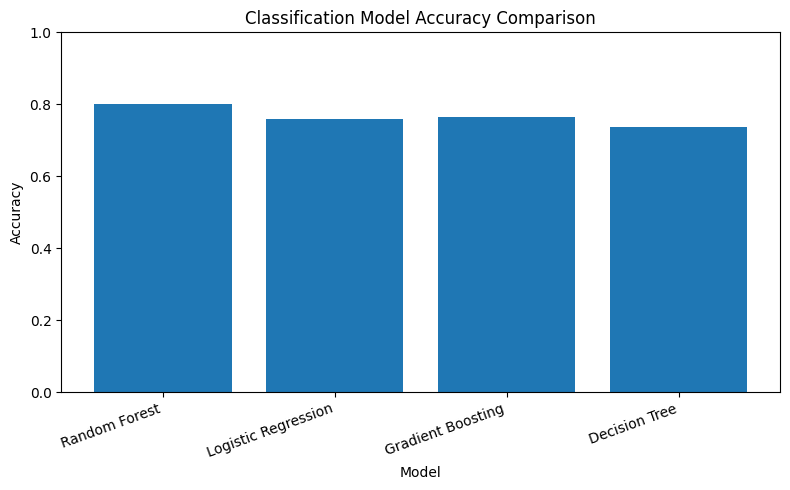

In [8]:
plt.figure(figsize=(8, 5))
plt.bar(classification_results_df["model"], classification_results_df["accuracy"] )
plt.title("Classification Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("figures/classification_accuracy_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


## 7. Best Classification Model

The best model is selected based on F1-score because the dataset may not be perfectly balanced.


In [9]:
best_clf_name = classification_results_df.iloc[0]["model"]
best_clf = trained_classification_models[best_clf_name]

y_pred_best = best_clf.predict(X_test)

print("Best classification model:", best_clf_name)
print(classification_report(y_test, y_pred_best, target_names=["Low popularity", "High popularity"]))


Best classification model: Random Forest
                 precision    recall  f1-score   support

 Low popularity       0.82      0.89      0.85       630
High popularity       0.75      0.64      0.69       337

       accuracy                           0.80       967
      macro avg       0.79      0.76      0.77       967
   weighted avg       0.80      0.80      0.80       967



## 8. Plot: Confusion Matrix

The confusion matrix shows how many songs were correctly and incorrectly classified as high or low popularity.


<Figure size 600x500 with 0 Axes>

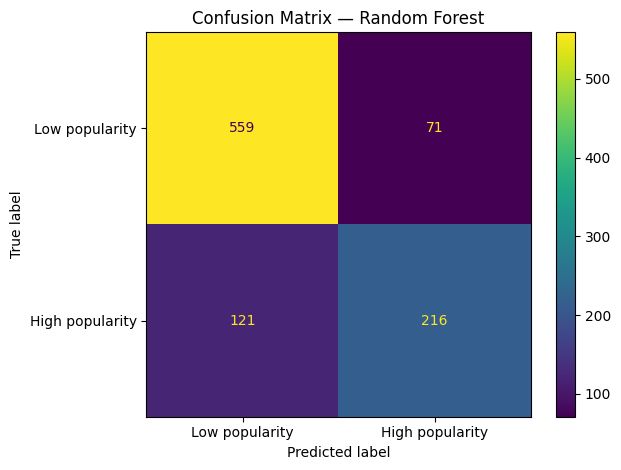

In [10]:
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_best,
    display_labels=["Low popularity", "High popularity"],
    values_format="d"
)
plt.title(f"Confusion Matrix — {best_clf_name}")
plt.tight_layout()
plt.savefig("figures/confusion_matrix_best_classifier.png", dpi=200, bbox_inches="tight")
plt.show()


## 9. Plot: ROC Curve

The ROC curve shows how well the classifier separates high-popularity songs from low-popularity songs across different thresholds.


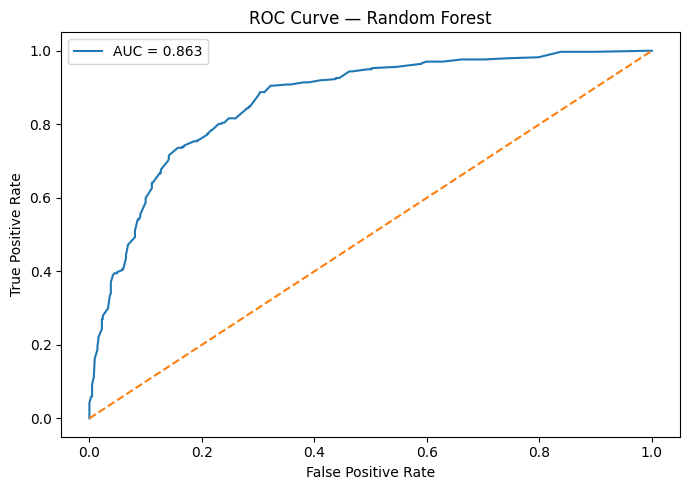

In [11]:
if hasattr(best_clf.named_steps["model"], "predict_proba"):
    y_prob = best_clf.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {best_clf_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig("figures/roc_curve_best_classifier.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("The selected model does not support predict_proba, so ROC curve is skipped.")


## 10. Plot: Feature Importance

For tree-based models, feature importance is directly available. For other models, permutation importance is used. This helps explain which features contribute most to the model predictions.


In [12]:
# Get feature names after preprocessing
feature_names = best_clf.named_steps["preprocessor"].get_feature_names_out()
model_obj = best_clf.named_steps["model"]

if hasattr(model_obj, "feature_importances_"):
    importances = model_obj.feature_importances_
elif hasattr(model_obj, "coef_"):
    importances = np.abs(model_obj.coef_[0])
else:
    importances = np.zeros(len(feature_names))

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(12)

importance_df

,feature,importance
2,num__loudness,0.097762
6,num__instrumentalness,0.094010
9,num__duration_ms,0.085478
5,num__acousticness,0.082252
1,num__energy,0.072619
4,num__valence,0.068169
0,num__danceability,0.067562
3,num__tempo,0.067380
8,num__speechiness,0.066688
7,num__liveness,0.064162


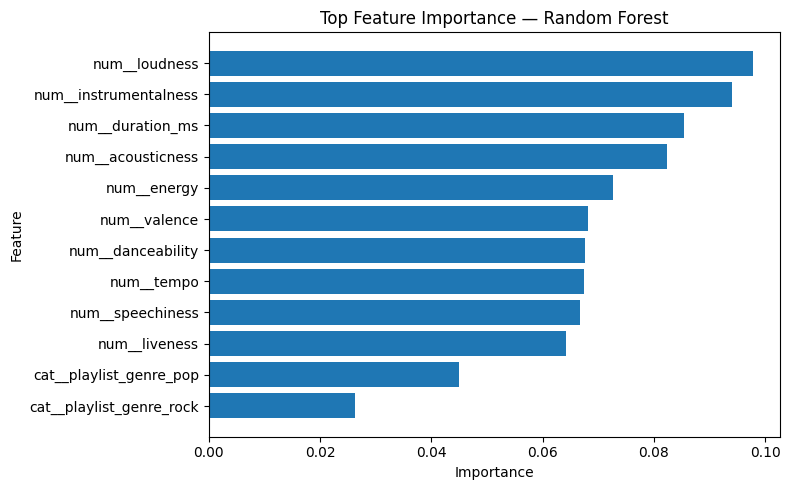

In [13]:
plt.figure(figsize=(8, 5))
plt.barh(importance_df["feature"][::-1], importance_df["importance"][::-1])
plt.title(f"Top Feature Importance — {best_clf_name}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("figures/feature_importance_best_classifier.png", dpi=200, bbox_inches="tight")
plt.show()


## 11. Regression Task: Predict Numeric Popularity Score

In addition to classification, we also predict the numeric `track_popularity` score. This is useful because the original Spotify dataset contains a popularity score between 0 and 100.

This task uses regression models and evaluates them with:

- RMSE
- MAE
- R²


In [15]:

reg_df = df.dropna(subset=["track_popularity"]).copy()

X_reg = reg_df[numeric_features + categorical_features].copy()
y_reg = reg_df["track_popularity"].astype(float)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42
)

print("Regression train shape:", X_train_reg.shape)
print("Regression test shape:", X_test_reg.shape)


Regression train shape: (3864, 11)
Regression test shape: (967, 11)


## 12. Regression Model Comparison

Multiple regression models are trained to predict the Spotify popularity score.


In [16]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

regression_results = []
trained_regression_models = {}

for name, model in regression_models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train_reg, y_train_reg)
    y_pred_reg = pipe.predict(X_test_reg)

    regression_results.append({
        "model": name,
        "rmse": rmse(y_test_reg, y_pred_reg),
        "mae": float(mean_absolute_error(y_test_reg, y_pred_reg)),
        "r2": float(r2_score(y_test_reg, y_pred_reg))
    })

    trained_regression_models[name] = pipe

regression_results_df = pd.DataFrame(regression_results).sort_values("rmse").reset_index(drop=True)
regression_results_df


,model,rmse,mae,r2
0,Random Forest,15.159907,11.301331,0.397382
1,Gradient Boosting,15.662063,12.149478,0.356798
2,Lasso,16.492972,12.915668,0.286741
3,Ridge,16.493510,12.886394,0.286695
4,Linear Regression,16.501444,12.879956,0.286008
5,ElasticNet,16.562329,13.153662,0.280730


## 13. Plot: Regression Model RMSE Comparison

Lower RMSE means better prediction performance.


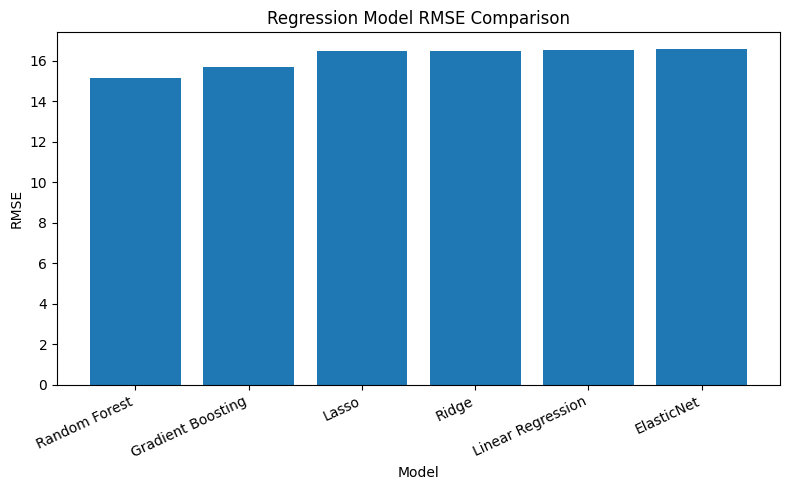

In [17]:
plt.figure(figsize=(8, 5))
plt.bar(regression_results_df["model"], regression_results_df["rmse"])
plt.title("Regression Model RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("figures/regression_rmse_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


## 14. Best Regression Model Diagnostics

The best regression model is selected based on the lowest RMSE.


In [18]:
best_reg_name = regression_results_df.iloc[0]["model"]
best_reg = trained_regression_models[best_reg_name]

y_pred_reg_best = best_reg.predict(X_test_reg)

rmse_val = rmse(y_test_reg, y_pred_reg_best)
mae_val = float(mean_absolute_error(y_test_reg, y_pred_reg_best))
r2_val = float(r2_score(y_test_reg, y_pred_reg_best))

print("Best regression model:", best_reg_name)
print("RMSE:", rmse_val)
print("MAE:", mae_val)
print("R²:", r2_val)


Best regression model: Random Forest
RMSE: 15.159907474644408
MAE: 11.301330575663563
R²: 0.3973816715844447


## 15. Plot: Actual vs Predicted Popularity

This plot compares the real Spotify popularity scores with the predicted scores. Points close to the diagonal line indicate better predictions.


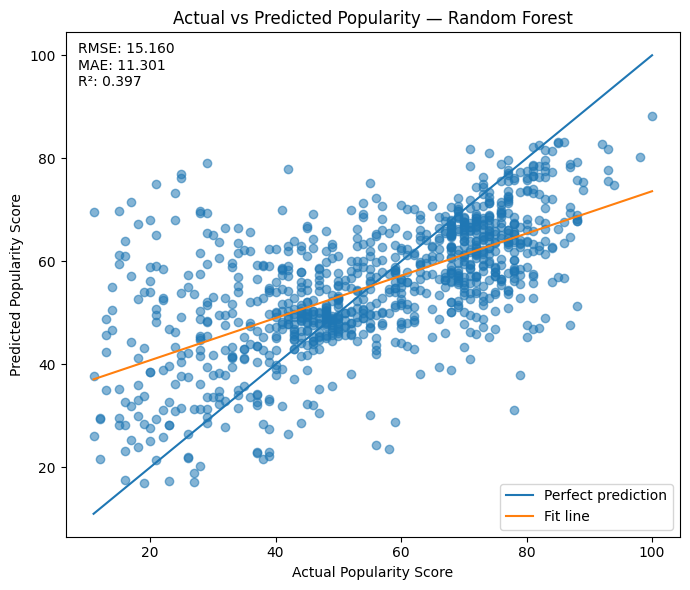

In [19]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test_reg, y_pred_reg_best, alpha=0.55)

lo = min(np.min(y_test_reg), np.min(y_pred_reg_best))
hi = max(np.max(y_test_reg), np.max(y_pred_reg_best))
plt.plot([lo, hi], [lo, hi], label="Perfect prediction")



b1, b0 = np.polyfit(y_test_reg, y_pred_reg_best, 1)
xx = np.linspace(lo, hi, 100)
plt.plot(xx, b1 * xx + b0, label="Fit line")

plt.xlabel("Actual Popularity Score")
plt.ylabel("Predicted Popularity Score")
plt.title(f"Actual vs Predicted Popularity — {best_reg_name}")
plt.text(0.02, 0.98,
         f"RMSE: {rmse_val:.3f}\nMAE: {mae_val:.3f}\nR²: {r2_val:.3f}",
         transform=plt.gca().transAxes, va="top")
plt.legend()
plt.tight_layout()
plt.savefig("figures/actual_vs_predicted_popularity.png", dpi=200, bbox_inches="tight")
plt.show()


## 16. Plot: Residual Distribution

Residuals show prediction errors. A residual close to 0 means the model predicted the song popularity accurately.


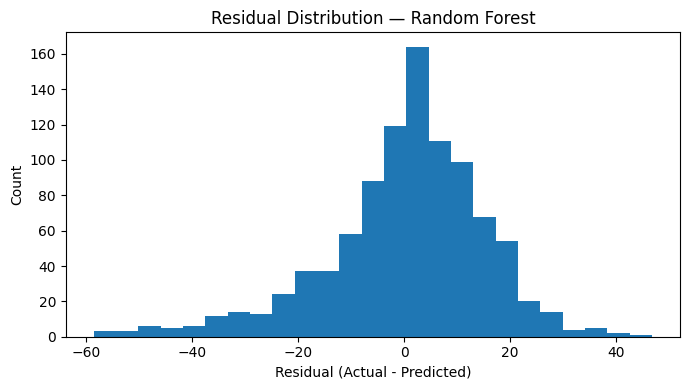

In [20]:
residuals = y_test_reg - y_pred_reg_best

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=25)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title(f"Residual Distribution — {best_reg_name}")
plt.tight_layout()
plt.savefig("figures/residual_distribution.png", dpi=200, bbox_inches="tight")
plt.show()


## 17. Plot: Average Predicted vs Actual Popularity by Genre

This plot gives a more interpretable view by comparing average actual and predicted popularity across playlist genres.


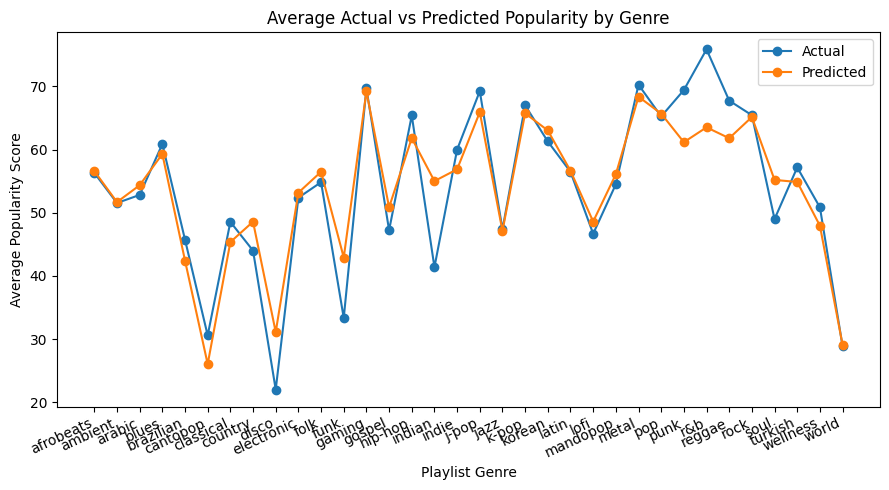

In [21]:
if "playlist_genre" in X_test_reg.columns:
    genre_eval = X_test_reg.copy()
    genre_eval["actual"] = y_test_reg.values
    genre_eval["predicted"] = y_pred_reg_best

    genre_avg = genre_eval.groupby("playlist_genre")[["actual", "predicted"]].mean().reset_index()

    plt.figure(figsize=(9, 5))
    plt.plot(genre_avg["playlist_genre"], genre_avg["actual"], marker="o", label="Actual")
    plt.plot(genre_avg["playlist_genre"], genre_avg["predicted"], marker="o", label="Predicted")
    plt.title("Average Actual vs Predicted Popularity by Genre")
    plt.xlabel("Playlist Genre")
    plt.ylabel("Average Popularity Score")
    plt.xticks(rotation=25, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.savefig("figures/genre_actual_vs_predicted.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("playlist_genre column not found, so genre-level plot is skipped.")


## 18. Regression Feature Importance

Permutation importance is used to understand which features are most useful for predicting the numeric popularity score.


In [22]:

reg_feature_names = best_reg.named_steps["preprocessor"].get_feature_names_out()
reg_model_obj = best_reg.named_steps["model"]

if hasattr(reg_model_obj, "feature_importances_"):
    reg_importances = reg_model_obj.feature_importances_
elif hasattr(reg_model_obj, "coef_"):
    reg_importances = np.abs(reg_model_obj.coef_)
else:
    reg_importances = np.zeros(len(reg_feature_names))

reg_importance_df = pd.DataFrame({
    "feature": reg_feature_names,
    "importance_mean": reg_importances
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

reg_importance_df

,feature,importance_mean
0,num__loudness,0.109455
1,num__duration_ms,0.099935
2,num__instrumentalness,0.090015
3,cat__playlist_genre_world,0.080145
4,num__danceability,0.067578
5,num__speechiness,0.065588
6,num__valence,0.064382
7,num__acousticness,0.062382
8,num__energy,0.059415
9,num__tempo,0.057709


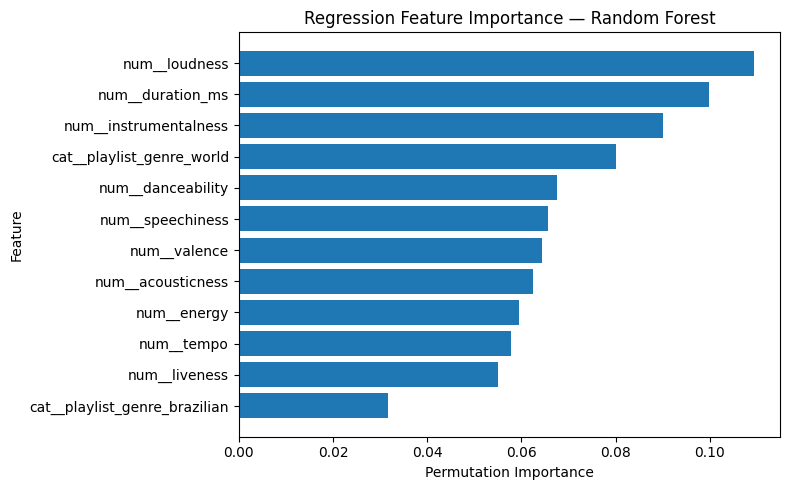

In [23]:
top_reg_importance = reg_importance_df.head(12)

plt.figure(figsize=(8, 5))
plt.barh(top_reg_importance["feature"][::-1], top_reg_importance["importance_mean"][::-1])
plt.title(f"Regression Feature Importance — {best_reg_name}")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("figures/regression_feature_importance.png", dpi=200, bbox_inches="tight")
plt.show()


## 19. Final Interpretation

The classification models were used to predict whether songs belong to the high-popularity or low-popularity group. The model comparison shows which algorithm performs best for this binary task. The confusion matrix and ROC curve provide more detailed evaluation beyond accuracy.

The regression models were used to predict the numeric Spotify popularity score. The actual-vs-predicted scatter plot shows how close the model predictions are to the real popularity values, while the residual histogram shows the distribution of errors.

Feature importance plots help interpret the model by showing which musical attributes, such as energy, loudness, danceability, valence, and tempo, contribute most to popularity prediction.

Overall, this ML section supports the project goal by showing that audio features can be used to predict song popularity, although popularity is also affected by external factors such as artist fame, marketing, playlist placement, and social trends that are not fully captured in the dataset.
